In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pandas as pd

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = True
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

In [3]:
RU = 25559  # km
mag = pd.concat([pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860124_ASC.csv'),
                 pd.read_csv('./pds_data/1.92s/data-u1-1_92s-asc/T860125_ASC.csv')],
                ignore_index=True)
pos = pd.read_csv('./pds_data/1.92s/vg2_positions_1_92s.csv')
mag['PDSTIME'] = pd.to_datetime(mag.PDSTIME, format='ISO8601', utc=True)
pos['PDSTIME'] = pd.to_datetime(pos.PDSTIME, format='ISO8601', utc=True)


df = mag.merge(pos, on='PDSTIME', how='inner')
r = pos['radius']/RU
theta = pos['colatitude']
phi = pos['longitude']

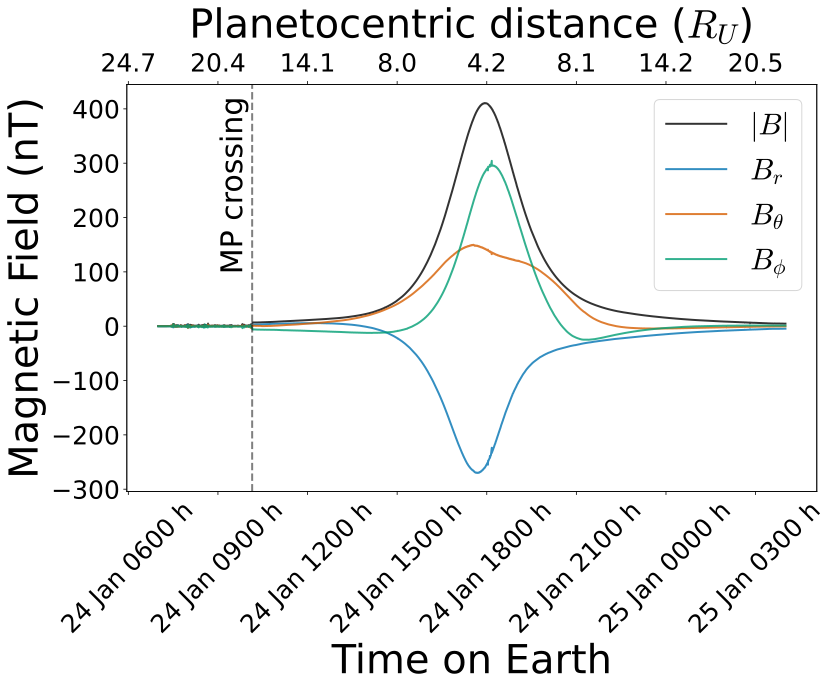

In [4]:
fig, ax = plt.subplots(figsize=(12, 10))

lw = 2
alpha = 0.8
colors = ["#0072B2", "#D55E00", "#009E73"]


bmag = np.sqrt(df['BR']**2 + df['BTheta']**2 + df['BPhi']**2)

ax.plot(df['PDSTIME'], bmag, label=r'$|B|$', linewidth=lw, alpha=alpha, color='k')
ax.plot(df['PDSTIME'], df['BR'], label=r'$B_r$', linewidth=lw, alpha=alpha, color=colors[0])
ax.plot(df['PDSTIME'], df['BTheta'], label=r'$B_\theta$', linewidth=lw, alpha=alpha, color=colors[1])
ax.plot(df['PDSTIME'], df['BPhi'], label=r'$B_\phi$', linewidth=lw, alpha=alpha, color=colors[2])
ax.set_xlabel('Time on Earth', fontsize=40)
ax.set_ylabel('Magnetic Field (nT)', fontsize=40)
ax.legend(fontsize=30)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H%M h'))
ax.tick_params(axis='both', which='major', labelsize=25)
ax.tick_params(axis='x', rotation=45)

# Align a top axis with the time ticks and label it with spacecraft distance.
time_ticks = ax.get_xticks()
time_num = mdates.date2num(df['PDSTIME'])
distance_ru = np.interp(time_ticks, time_num, df['radius'] / RU)
ax_distance = ax.twiny()
ax_distance.set_xlim(ax.get_xlim())
ax_distance.set_xticks(time_ticks)
ax_distance.set_xticklabels([f'{distance:.1f}' for distance in distance_ru])
ax_distance.set_xlabel(r'Planetocentric distance ($R_U$)', fontsize=40, labelpad=15)
ax_distance.tick_params(axis='x', which='major', labelsize=25)

idx = np.argmin(np.abs(df['radius'][:len(df)//2] - 18 * RU))
ax.axvline(df['PDSTIME'].iloc[idx], color='k', linestyle='--', linewidth=2, alpha=0.5)
ax.text(df['PDSTIME'].iloc[idx-2000], 0.95 * ax.get_ylim()[1], 'MP crossing', rotation=90, verticalalignment='top', fontsize=30)

fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_magnetic_field_vg2.pdf', bbox_inches='tight')
plt.show()

In [6]:
mask = r <= 12

r = r[mask]; theta = theta[mask]; phi = phi[mask]
df = df[mask]


In [8]:
thetamax = 90-theta.max()*180/np.pi
thetamin = 90-theta.min()*180/np.pi
print(thetamin, thetamax)

39.63894743000001 -78.08532097
